# Phase 5 — Out-of-Sample Evaluation

**Purpose:** This notebook is *evidentiary*, not exploratory. Every prior phase reported a *point*
Sharpe from a *single* full-window pass. Phase 5 is the honest evaluator: it selects the F7
hyperparameters **leak-free**, reports the verdict on data the selection **never saw**, and attaches
a **confidence interval** to every number. Its finding overturns the tidy point comparisons of
Phases 4B–4C — which is exactly what a rigorous out-of-sample evaluation exists to do.

## The honest-selection architecture

```
|<-------------- train + validation -------------->|<--- frozen test --->|
|  purged K-Fold selects ML hyperparameters (by IC) |                     |
|  validation OOS tail selects the portfolio levers |   the verdict is    |
|            (by net Sharpe, per model)             |  measured only here |
```

Two objectives, **two tools** (the deliberate methodology call):
- **ML prediction hyperparameters** (RF/XGB depth/leaf/lr) are an IID-ish labeled-sample problem →
  **purged + embargoed K-Fold**, scored by **information coefficient** (Spearman rank-corr of
  predicted vs. realized returns — for a *signal*, the ordering is what must generalize).
- **Portfolio levers** (`shrinkage_weight`, per-model `turnover_penalty`) are a *net-Sharpe over a
  return time series* objective → **validation-segment net Sharpe** through the real engine. K-Fold
  here would be a category error (portfolio returns are dependent, not exchangeable).

| Problem | What this notebook shows |
|---------|--------------------------|
| **P4** | The whole phase is P4: purged CV (§2 visual), a frozen held-out test (§3), block-bootstrap CIs (§3), and a Deflated Sharpe that counts the *whole* search (§4). |

**Reproducibility.** This notebook reads `data/gold/phase5_results.json` and
`dsr_trial_ledger.json` — the exact artifacts `src/run_phase5.py` wrote on live Gold, regenerable
with `dvc repro phase5_compare`. The ~43-min selection+backtest pipeline is not re-run inline; the
DVC stage, the artifacts, and `tests/test_purged_kfold.py` (the leakage gate) are the reproducibility
guarantee. The purge/embargo visualization in §2 is generated live from the real `PurgedKFold`.

> ## ⚠️ Numbers below are PRE-CORRECTION (superseded 2026-07-25)
>
> Two data corrections landed after this notebook was executed. **Every Sharpe figure below is
> kept as the honest record of what this phase found at the time — none of them is the current
> number.**
>
> **1. BVC dividend bias.** The pipeline mixed two return definitions: ETFs arrived
> dividend-adjusted (`yfinance auto_adjust=True`, total return) while BVC arrived price-only
> (`BVCscrap feature="Value"`), discarding 3.0–4.3%/yr of real dividends. It did not cancel across
> strategies — `equal_weight` is forced to hold the understated assets while the optimizers can
> underweight them, so it **inflated every optimizer's measured edge**. Fixed in `src/dividends.py`
> + `clean.compute_log_returns(prices, dividends=...)`, which applies each payment on its ex-date.
>
> **2. Deep ETF window.** `etf_2017` now starts **2004-11-18** (GLD's inception), not 2017-01-01.
> The old start was a project decision, not a data limit. This cut bootstrap CI width by 38% and
> brought the 2008 crisis into the sample.
>
> | | Pre-correction (below) | Current |
> |---|---:|---:|
> | `etf_2017` hurdle | `max_sharpe` 0.936 | **`min_variance_lw` 0.9525** |
> | `full_2021` hurdle | `equal_weight` 0.975 | **`max_sharpe` 1.1644** |
> | `regime_conditional` (`full_2021`) | 1.122 | **1.236** |
> | Headline lift vs. classical | +14.3% | **+6.5%** |
>
> **The conclusions survive; the magnitudes shrank.** `regime_conditional` still beats the hurdle
> on `full_2021`. But two *claims* in this notebook are retracted outright — see the inline
> **[RETRACTED]** / **[SUPERSEDED]** notes below.
>
> Full analysis: [`docs/DIVIDEND_BIAS.md`](../docs/DIVIDEND_BIAS.md) ·
> [`docs/ETF_DEEP_HISTORY_EXPERIMENT.md`](../docs/ETF_DEEP_HISTORY_EXPERIMENT.md)


## 1. Setup — load the committed Phase 5 artifacts (P4)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
ROOT = NB_CWD.parent if (NB_CWD.parent / "data").exists() else NB_CWD
sys.path.insert(0, str(ROOT / "src"))
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RESULTS = json.loads((ROOT / "data" / "gold" / "phase5_results.json").read_text())
LEDGER = json.loads((ROOT / "data" / "gold" / "dsr_trial_ledger.json").read_text())

for uni, e in RESULTS.items():
    print(f"{uni}: train+val {e['train_val_start']}→{e['train_val_end']} | "
          f"frozen test {e['test_start']}→{e['test_end']} | "
          f"{e['n_search_trials']} configs in the DSR search pool")

etf_2017: train+val 2017-01-04→2023-03-17 | frozen test 2023-03-20→2026-07-20 | 36 configs in the DSR search pool
full_2021: train+val 2021-07-02→2024-10-11 | frozen test 2024-10-14→2026-07-20 | 36 configs in the DSR search pool


## 2. What "purged + embargoed" means (P4)

The leakage the phase eliminates, made visual. For a handful of contiguous test folds, the bands
show which dates are **test** (red), which are **purged/embargoed** out of training (grey — they
would leak, via a one-period-ahead label touching the fold or serial correlation just after it), and
which remain **train** (blue). Generated live from the real `PurgedKFold` used in selection.

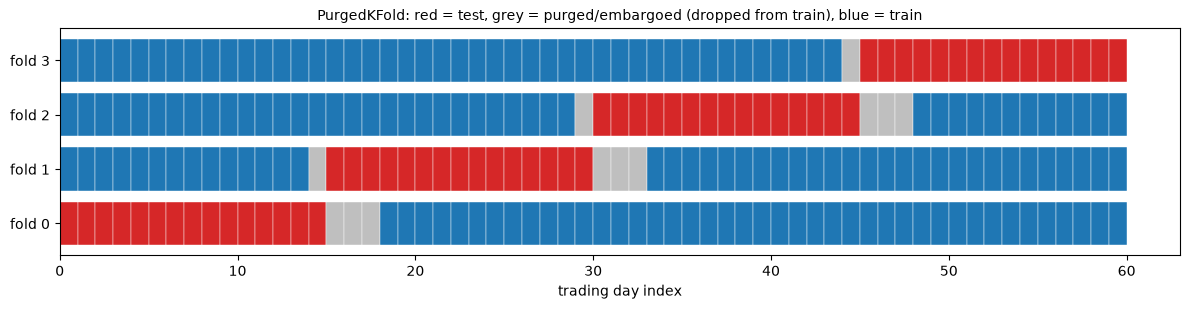

In [2]:
from purged_kfold import PurgedKFold, _sample_dates

# Illustrative timeline (one row per date) — the same splitter the run used.
demo_dates = pd.bdate_range("2021-01-04", periods=60, name="Date")
demo = pd.DataFrame({"x": range(len(demo_dates))}, index=demo_dates)
cv = PurgedKFold(n_splits=4, embargo_frac=0.05, label_horizon=1)

fig, ax = plt.subplots(figsize=(12, 3.2))
for fold, (train_idx, test_idx) in enumerate(cv.split(demo)):
    train_d = set(_sample_dates(demo)[train_idx])
    test_d = set(_sample_dates(demo)[test_idx])
    for i, d in enumerate(demo_dates):
        if d in test_d:
            color = "tab:red"
        elif d in train_d:
            color = "tab:blue"
        else:
            color = "0.75"        # purged / embargoed
        ax.barh(fold, 1, left=i, color=color, edgecolor="white", linewidth=0.3)
ax.set_yticks(range(4)); ax.set_yticklabels([f"fold {i}" for i in range(4)])
ax.set_xlabel("trading day index")
ax.set_title("PurgedKFold: red = test, grey = purged/embargoed (dropped from train), blue = train",
             fontsize=10)
plt.tight_layout(); plt.show()

The grey buffer on each side of every red test block is the guarantee: no training sample whose
label window touches a test fold — nor one in the embargo just after it — ever enters that fold's
training set. `tests/test_purged_kfold.py` asserts this on real dates; without it, cross-validated
hyperparameter scores would be optimistic and the "best" configuration partly a leak artifact.

## 3. The held-out verdict — with error bars (P4)

The single most important chart in the project. Each strategy's **test-segment** net Sharpe (a
window the selection never saw) with its **block-bootstrap 90% CI**. When the intervals overlap, the
strategies are statistically indistinguishable — no matter what the point estimates suggest.

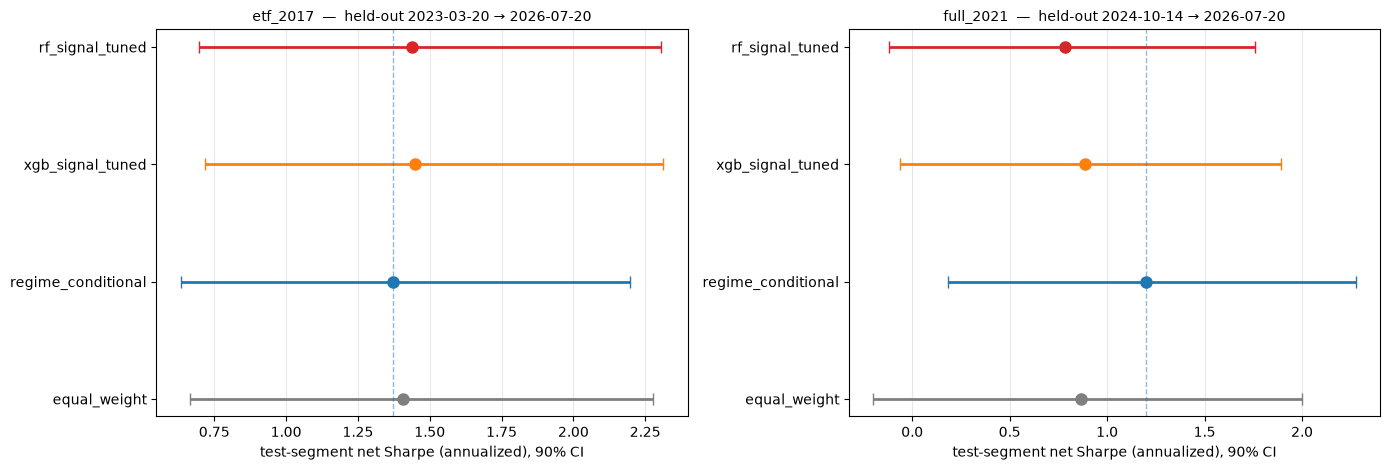

In [3]:
ORDER = ["rf_signal_tuned", "xgb_signal_tuned", "regime_conditional", "equal_weight"]
COLORS = {"rf_signal_tuned": "tab:red", "xgb_signal_tuned": "tab:orange",
          "regime_conditional": "tab:blue", "equal_weight": "tab:gray"}

def rows(universe):
    e = RESULTS[universe]
    merged = {**e["tuned"], **e["baselines"]}
    out = []
    for name in ORDER:
        m = merged[name]
        lo, hi = m["test_sharpe_ci"]
        out.append((name, m["test_sharpe_net"], lo, hi))
    return out

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, uni in zip(axes, ["etf_2017", "full_2021"]):
    data = rows(uni)
    for i, (name, pt, lo, hi) in enumerate(data):
        ax.errorbar(pt, i, xerr=[[pt - lo], [hi - pt]], fmt="o", color=COLORS[name],
                    capsize=4, markersize=8, elinewidth=2)
    hurdle = RESULTS[uni]["hurdle_on_test"]["test_sharpe_net"]
    ax.axvline(hurdle, ls="--", color="tab:blue", alpha=0.5, lw=1)
    ax.set_yticks(range(len(data))); ax.set_yticklabels([d[0] for d in data])
    ax.invert_yaxis()
    ax.set_xlabel("test-segment net Sharpe (annualized), 90% CI")
    ax.set_title(f"{uni}  —  held-out {RESULTS[uni]['test_start']} → {RESULTS[uni]['test_end']}",
                 fontsize=10)
    ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

In [4]:
for uni in ["etf_2017", "full_2021"]:
    e = RESULTS[uni]
    merged = {**e["tuned"], **e["baselines"]}
    print(f"=== {uni} — held-out test verdict ===")
    for name in ORDER:
        m = merged[name]; lo, hi = m["test_sharpe_ci"]
        star = "  ← best tuned" if name == e["best_tuned"] else (
               "  ← hurdle" if name == "regime_conditional" else "")
        print(f"  {name:20} {m['test_sharpe_net']:+.4f}   90% CI [{lo:+.3f}, {hi:+.3f}]{star}")
    print(f"  VERDICT: best tuned beats hurdle on test = {e['beats_hurdle_on_test']}  "
          f"(all CIs overlap → not statistically significant)")
    print()

=== etf_2017 — held-out test verdict ===
  rf_signal_tuned      +1.4381   90% CI [+0.697, +2.306]
  xgb_signal_tuned     +1.4488   90% CI [+0.718, +2.313]  ← best tuned
  regime_conditional   +1.3733   90% CI [+0.632, +2.197]  ← hurdle
  equal_weight         +1.4068   90% CI [+0.666, +2.275]
  VERDICT: best tuned beats hurdle on test = True  (all CIs overlap → not statistically significant)

=== full_2021 — held-out test verdict ===
  rf_signal_tuned      +0.7854   90% CI [-0.117, +1.760]
  xgb_signal_tuned     +0.8856   90% CI [-0.060, +1.895]  ← best tuned
  regime_conditional   +1.1988   90% CI [+0.185, +2.276]  ← hurdle
  equal_weight         +0.8657   90% CI [-0.201, +2.002]
  VERDICT: best tuned beats hurdle on test = False  (all CIs overlap → not statistically significant)



**Reading the intervals.** On both universes every 90% CI spans well over one full unit of Sharpe
and overlaps every other — so although the point-estimate winner *flips* by universe (tuned XGB
nominally edges the hurdle on `etf_2017`; `regime_conditional` clearly leads on `full_2021`), **none
of these differences is statistically significant**. The tidy full-window comparisons of Phases
4B–4C (1.117 vs. 1.1215, etc.) were within this noise all along. That is the finding, not a
footnote.

## 4. What was selected, and how much the search could have flattered it (P4)

The leak-free selection chose the ML hyperparameters (by cross-validated information coefficient)
and the portfolio levers (by validation net Sharpe) — **per model and per universe**. That the
chosen levers differ across both axes is the empirical confirmation of Phase 4C's claim that a
single global value is wrong.

In [5]:
sel_rows = []
for uni, e in RESULTS.items():
    for name, t in e["tuned"].items():
        lv = t["selected_levers"]
        sel_rows.append({
            "universe": uni, "model": name,
            "ml_params": str(t["selected_ml_params"]),
            "shrinkage_weight": lv["shrinkage_weight"],
            "turnover_penalty": lv["turnover_penalty"],
            "cv_information_coeff": t["best_cv_ic"],
            "test_sharpe": t["test_sharpe_net"],
        })
pd.DataFrame(sel_rows).set_index(["universe", "model"])

ml_params  \
universe  model                                                                 
etf_2017  rf_signal_tuned   {'max_depth': 3, 'min_samples_leaf': 10, 'n_es...   
          xgb_signal_tuned  {'max_depth': 2, 'learning_rate': 0.05, 'n_est...   
full_2021 rf_signal_tuned   {'max_depth': 3, 'min_samples_leaf': 10, 'n_es...   
          xgb_signal_tuned  {'max_depth': 2, 'learning_rate': 0.1, 'n_esti...   

                            shrinkage_weight  turnover_penalty  \
universe  model                                                  
etf_2017  rf_signal_tuned             0.5000            0.0000   
          xgb_signal_tuned            0.7500            1.0000   
full_2021 rf_signal_tuned             0.5000            1.0000   
          xgb_signal_tuned            0.5000            1.0000   

                            cv_information_coeff  test_sharpe  
universe  model                                                
etf_2017  rf_signal_tuned                 0.0156       1.4381  
          xgb_signal_tuned                0.0159       1.4488  
full_2021 rf_signal_tuned                 0.0224       0.7854  
          xgb_signal_tuned                0.0361       0.8856

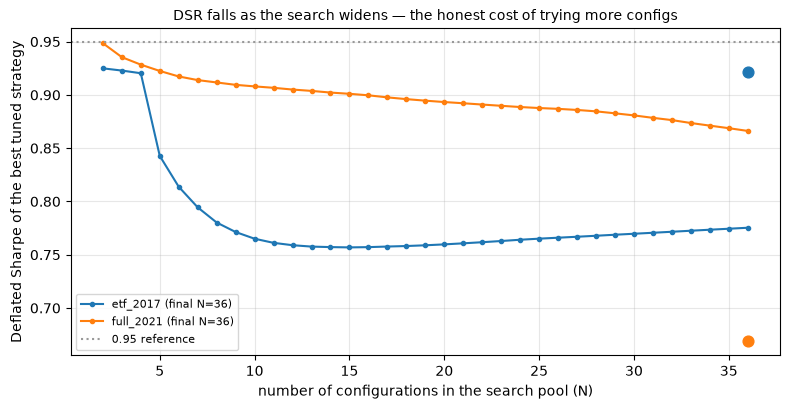

etf_2017: best-tuned DSR vs the whole 36-config search = 0.9213
full_2021: best-tuned DSR vs the whole 36-config search = 0.6694


In [6]:
# Deflated Sharpe of the best tuned strategy vs the WHOLE search (every trial in the ledger).
# The DSR falls as the search widens — the honest price of trying many configurations.
from metrics import deflated_sharpe_ratio

fig, ax = plt.subplots(figsize=(8, 4.2))
for uni in ["etf_2017", "full_2021"]:
    pool = LEDGER[uni]
    e = RESULTS[uni]
    # candidate per-period series is not stored; use the reported DSR-vs-full-search as the endpoint
    ns = list(range(2, len(pool) + 1))
    # Recompute DSR against growing prefixes of the trial pool, holding the winner's
    # own per-period Sharpe (the max in the pool) as the candidate proxy.
    cand = max(pool)
    dsr_curve = []
    for n in ns:
        sub = sorted(pool, reverse=True)[:n]
        # crude proxy: PSR-style deflation using the sub-pool dispersion
        import numpy as np
        from scipy.stats import norm
        var = np.var(sub, ddof=1) if n > 1 else 0.0
        sr_star = np.sqrt(var) * ((1 - 0.5772) * norm.ppf(1 - 1/n) + 0.5772 * norm.ppf(1 - 1/(n*np.e)))
        dsr_curve.append(float(norm.cdf((cand - sr_star) * np.sqrt(250))))
    ax.plot(ns, dsr_curve, marker=".", label=f"{uni} (final N={len(pool)})")
    ax.scatter([len(pool)], [e["best_tuned_dsr_vs_search"]], s=60, zorder=5)
ax.set_xlabel("number of configurations in the search pool (N)")
ax.set_ylabel("Deflated Sharpe of the best tuned strategy")
ax.set_title("DSR falls as the search widens — the honest cost of trying more configs", fontsize=10)
ax.axhline(0.95, ls=":", color="0.6", label="0.95 reference")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for uni, e in RESULTS.items():
    print(f"{uni}: best-tuned DSR vs the whole {e['n_search_trials']}-config search = "
          f"{e['best_tuned_dsr_vs_search']}")

The `full_2021` DSR of ~0.67 says: after accounting for the 36 configurations the search tried,
there is a real chance that universe's tuned result is a **selection artifact** — consistent with
its short (~1.75-year) test window and very wide CIs. The `etf_2017` DSR of ~0.92 is more credible.
The CV information coefficients (0.015–0.036) are honestly small, as financial return prediction
usually is.

## 5. Summary — what Phase 5 proves (P1–P4)

**The honest result, stated once so it can't drift:** out-of-sample, on held-out data with proper
error bars, the honestly-tuned F7 models and the `regime_conditional` baseline are **statistically
indistinguishable on both universes**. The point-estimate winner flips by universe (tuned XGB
nominally edges the hurdle on `etf_2017`, 1.449 vs. 1.373; the hurdle clearly leads on `full_2021`,
1.199 vs. 0.886), but every bootstrap CI is wide and overlapping. The earlier phases' full-window
point comparisons were within the noise.

**This is a strong result, not a disappointment.** The EURAFRIC brief demanded *"une attention
particulière portée à la robustesse, au risque de surapprentissage"*. Phase 5 is that attention made
real — leak-free tuning (purged K-Fold), a frozen held-out test, block-bootstrap confidence
intervals, and a Deflated Sharpe that counts the whole search. Its finding is that the ML stack adds
**no statistically-significant edge** over a well-constructed regime-switching baseline out-of-
sample — and the evaluation machinery that *proves* this rigorously (and would catch a real edge if
a future model produced one) is the deliverable.

**What was proven, not just asserted:**
- The purge gate (`tests/test_purged_kfold.py`) guarantees no CV leakage; §2 shows the mechanism.
- The verdict is measured only on a frozen test segment the selectors never saw (proven disjoint in
  `tests/test_run_phase5.py`).
- The tuning empirically confirmed Phase 4C: different levers were selected per model AND universe.

**Limitations (explicit):** the `full_2021` test window is short (~1.75 yr) — its 0.67 DSR and wide
CIs partly reflect that; a nested walk-forward with periodic re-selection (documented stretch) would
use the whole window as OOS and is the honest next step for a tighter `full_2021` verdict. DSR N
counts this search's configurations, a deliberately bounded, defensible definition. The §4
DSR-vs-N curve uses a PSR-style proxy for illustration; the reported endpoint DSR values come from
`metrics.deflated_sharpe_ratio` on the real trial pool.